Ne pas faire un simple split --> TimeSeriesSplit

In [ ]:
%pip install --quiet numpy pandas matplotlib scikit-learn torch


Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


KeyboardInterrupt: 

In [ ]:
# Visualization helper
def plot_narx_data(U: np.ndarray, Y: np.ndarray, title: str):
    time_steps = np.arange(U.shape[0])

    plt.figure(figsize=(12, 8))

    plt.subplot(2, 1, 1)
    if U.shape[1] == 1:
        plt.plot(time_steps, U[:, 0], label="u", color="blue")
    else:
        plt.plot(time_steps, U[:, 0], label="u1", color="blue")
        plt.plot(time_steps, U[:, 1], label="u2", color="orange")
    plt.title(f"{title} - Inputs")
    plt.xlabel("Time Step")
    plt.ylabel("Input Value")
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(time_steps, Y[:, 0], label="y1", color="green")
    plt.plot(time_steps, Y[:, 1], label="y2", color="red")
    plt.title(f"{title} - Outputs")
    plt.xlabel("Time Step")
    plt.ylabel("Output Value")
    plt.legend()

    plt.tight_layout()
    plt.show()

Download complete.


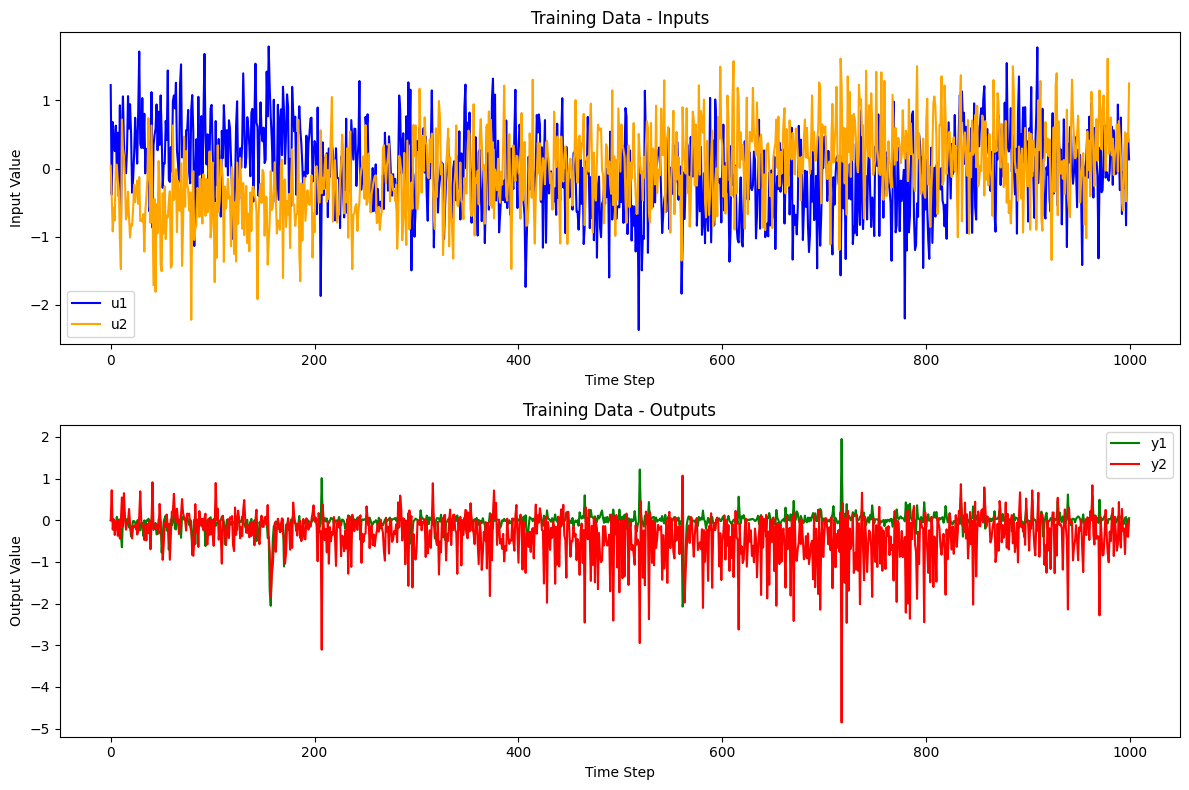

(1000, 2) (1000, 2)
(1000, 2) (1000, 2)


In [6]:
# Download the data
DATA_DOWNLOAD = "https://www.dropbox.com/scl/fi/5h60ixfu4olod5nmp2c58/StudentdataNARX.npz?rlkey=71g3dmm6oo25slyh4kekmt4pg&dl=1"

DATA_DIRECTORY = "data"
DATA_FILE = "StudentdataNARX.npz"
DATA_PATH = os.path.join(DATA_DIRECTORY, DATA_FILE)

os.makedirs(DATA_DIRECTORY, exist_ok=True)
if not os.path.exists(DATA_PATH):
    import urllib.request
    print("Downloading data...")
    urllib.request.urlretrieve(DATA_DOWNLOAD, DATA_PATH)
    print("Download complete.")
else:
    print("Data already exists. Skipping download.")

# Load the data
data = np.load(DATA_PATH, allow_pickle=True)

U_train = data["Utr"]
Y_train = data["Ytr"]
U_test_1 = data["Uts1"]
U_test_2 = data["Uts2"]

# Visualize the training data
plot_narx_data(U_train, Y_train, "Training Data")
print(U_train.shape, Y_train.shape)
print(U_test_1.shape, U_test_2.shape)

# Étape 1 : Simulation des systèmes pilotes NARX1 et NARX2

Dans cette étape, nous simulons deux systèmes NARX dont les équations
sont connues. L'objectif est de générer des données d'entraînement et
de test pour développer et valider notre pipeline avant de l'appliquer
aux données réelles.

NARX1 est un système à une entrée et deux sorties.
Ses équations font intervenir un terme sin() ce qui le rend non-linéaire.

NARX2 est un système à deux entrées et deux sorties.
Ses équations font intervenir des produits de sorties passées,
ce qui peut causer des instabilités numériques.

In [8]:
import numpy as np
import pandas as pd

# =====================================================
# SIMULATE NARX1 (1 input, 2 outputs)
# =====================================================

def simulate_narx1(N: int = 1000,
                   sigma: tuple = (0.1, 0.1),
                   seed: int = 42) -> tuple:
    """
    Simulate pilot NARX1 : 1 input, 2 coupled outputs.

    System equations (project spec eq. 5):
        y1(k+1) = 0.5*y2(k-1) + sin(y2(k)) + 0.3*u(k-1) + w1(k+1)
        y2(k+1) = 0.5*y1(k-1) + sin(y1(k)) + 0.2*u(k)   + w2(k+1)

    Key design choices:

    - INPUT DISTRIBUTION (U[-1,1]):
        Ensures persistent excitation of the system.
        u(0)=0 per project specification.

    - NOISE (Gaussian N(0, σ²)):
        Required by the project specification.
        sigma=0.1 gives realistic SNR (~20–26 dB).

    - INITIAL CONDITIONS:
        y1(0)=y2(0)=u(0)=0 as required by the project.

    - LOOP START:
        Start at k=1 because the equations require y(k-1).

    Returns:
        u : shape (N,1)
        y : shape (N,2)
    """
    np.random.seed(seed)

    # u(0)=0, then uniform excitation
    u = np.zeros((N, 1))
    u[1:] = np.random.uniform(-1, 1, size=(N-1, 1))

    # Outputs initialized to zero
    y = np.zeros((N, 2))

    # Gaussian noise
    w1 = np.random.normal(0, sigma[0], size=N)
    w2 = np.random.normal(0, sigma[1], size=N)

    # Simulation loop
    for k in range(1, N - 1):
        y[k+1, 0] = (0.5 * y[k-1, 1]
                     + np.sin(y[k, 1])
                     + 0.3 * u[k-1, 0]
                     + w1[k])

        y[k+1, 1] = (0.5 * y[k-1, 0]
                     + np.sin(y[k, 0])
                     + 0.2 * u[k, 0]
                     + w2[k])

    return u, y


# =====================================================
# SIMULATE NARX2 (2 inputs, 2 outputs)
# =====================================================

def simulate_narx2(N: int = 1000,
                   sigma: tuple = (0.05, 0.05),
                   seed: int = 42) -> tuple:
    """
    Simulate pilot NARX2 : 2 inputs, 2 coupled outputs.

    System equations (project spec eq. 6):
        y1(k+1) = [y1(k)*y1(k-1)*y1(k-2)*(y1(k-2)-1)*u2(k-1)+u2(k)]
                  / [1 + y2(k-1)^2 + y2(k-2)^2] + w1(k+1)

        y2(k+1) = [y2(k)*y2(k-1)*y2(k-2)*(y2(k-2)-1)*u1(k-1)+u1(k)]
                  / [1 + y1(k-1)^2 + y1(k-2)^2] + w2(k+1)

    Key design choices:

    - NUMERICAL STABILITY:
        NARX2 contains cubic products → risk of divergence.
        We clip outputs to [-5,5] to prevent overflow.

    - SMALLER SIGMA:
        sigma=0.05 avoids noise amplification through cubic terms.

    - INITIAL CONDITIONS:
        u(0)=0, y(0)=y(1)=0 per project spec.

    Returns:
        u : shape (N,2)
        y : shape (N,2)
    """
    np.random.seed(seed)

    # u(0)=0, then uniform excitation
    u = np.zeros((N, 2))
    u[1:] = np.random.uniform(-1, 1, size=(N-1, 2))

    y = np.zeros((N, 2))
    w1 = np.random.normal(0, sigma[0], size=N)
    w2 = np.random.normal(0, sigma[1], size=N)

    # Simulation loop (start at k=2)
    for k in range(2, N - 1):
        num1 = (y[k,0] * y[k-1,0] * y[k-2,0]
                * (y[k-2,0] - 1) * u[k-1,1] + u[k,1])
        den1 = 1 + y[k-1,1]**2 + y[k-2,1]**2

        num2 = (y[k,1] * y[k-1,1] * y[k-2,1]
                * (y[k-2,1] - 1) * u[k-1,0] + u[k,0])
        den2 = 1 + y[k-1,0]**2 + y[k-2,0]**2

        # Clipping for stability
        y[k+1, 0] = np.clip(num1/den1 + w1[k], -5, 5)
        y[k+1, 1] = np.clip(num2/den2 + w2[k], -5, 5)

    return u, y


# =====================================================
# GENERATE TRAIN/TEST PILOT DATASETS
# =====================================================

def generate_pilot_dataset(simulator,
                           train_length: int = 1000,
                           test_length:  int = 500,
                           sigma: tuple = (0.1, 0.1),
                           seed: int = 42,
                           fix_basin: bool = False) -> dict:
    """
    Generate train/test datasets for a pilot NARX system.

    - TRAIN LENGTH = 1000:
        Matches real dataset size.

    - TEST LENGTH = 500:
        Long enough for multi-step prediction evaluation.

    - DIFFERENT SEEDS:
        Train uses seed, test uses seed+1.
        Ensures generalization to unseen inputs.

    - fix_basin (NARX1 only):
        NARX1 is bistable (two attractors ±2).
        We ensure train and test belong to the same basin.
    """
    Utr, Ytr = simulator(train_length, sigma, seed)

    if fix_basin:
        train_mean = Ytr[:, 0].mean()
        found = False

        for offset in range(1, 50):
            Uts, Yts = simulator(test_length, sigma, seed + offset)
            test_mean = Yts[:, 0].mean()

            if np.sign(train_mean) == np.sign(test_mean):
                print(f"  ✓ Same basin found at seed+{offset}")
                found = True
                break

        if not found:
            print("  ⚠ No matching basin found, using seed+1")
            Uts, Yts = simulator(test_length, sigma, seed + 1)

    else:
        Uts, Yts = simulator(test_length, sigma, seed + 1)

    return {
        "Utr": Utr,
        "Ytr": Ytr,
        "Uts": Uts,
        "Yts": Yts,
        "train_length": train_length,
        "test_length": test_length,
        "sigma1": sigma[0],
        "sigma2": sigma[1],
    }


Generating NARX1...
  ✅ Same basin found at seed+2 (train μ=1.847, test μ=1.847)
Generating NARX2...

=== Sanity Checks ===

NARX1 ✅
  Utr shape : (1000, 1)
  Ytr shape : (1000, 2)
  Uts shape : (500, 1)
  Yts shape : (500, 2)
  NaN : False | Inf : False
  y1 mean=1.847 std=0.263
  y2 mean=1.845 std=0.253

NARX2 ✅
  Utr shape : (1000, 2)
  Ytr shape : (1000, 2)
  Uts shape : (500, 2)
  Yts shape : (500, 2)
  NaN : False | Inf : False
  y1 mean=0.003 std=0.429
  y2 mean=-0.017 std=0.466


,Pilot,Inputs,Outputs,Train N,Test N,σ1,σ2,Nonlinearity,Stability,Clipping
0,NARX1,1,2,1000,500,0.10,0.10,sin(),Bistable (±2),No
1,NARX2,2,2,1000,500,0.05,0.05,cubic products,"Clipped [-5,5]",Yes


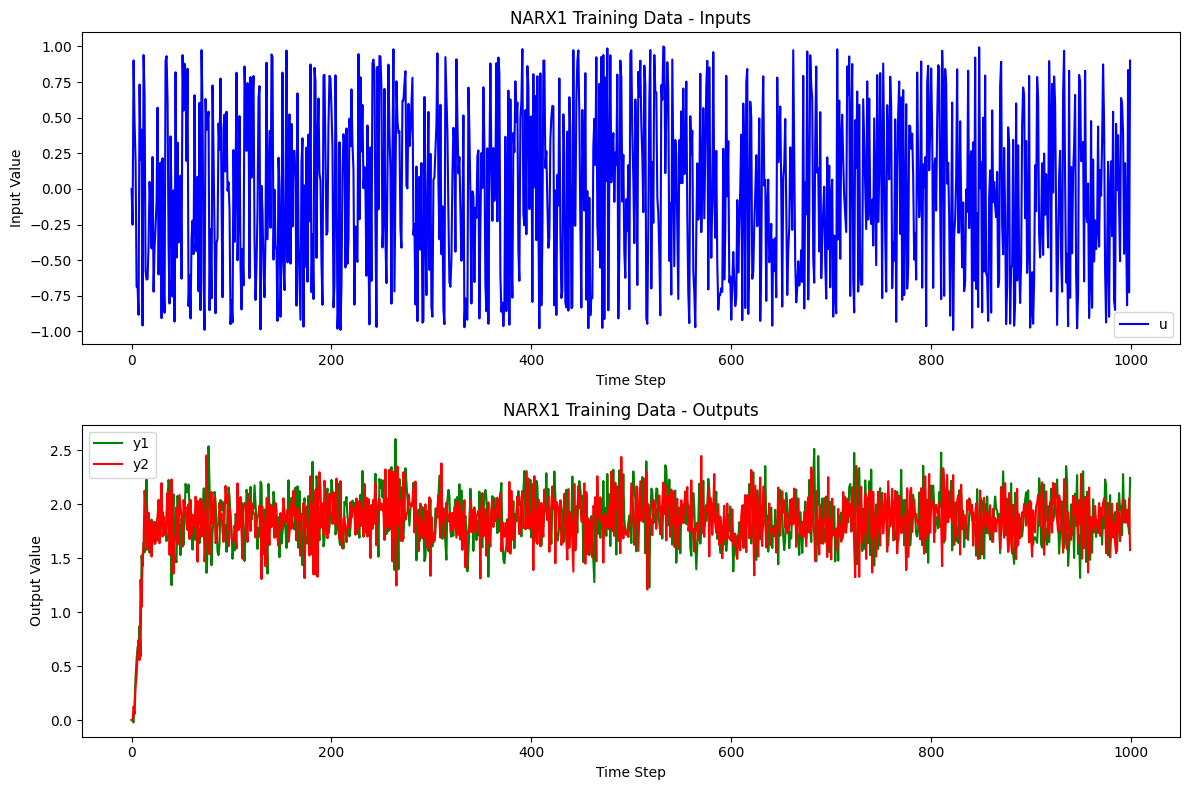

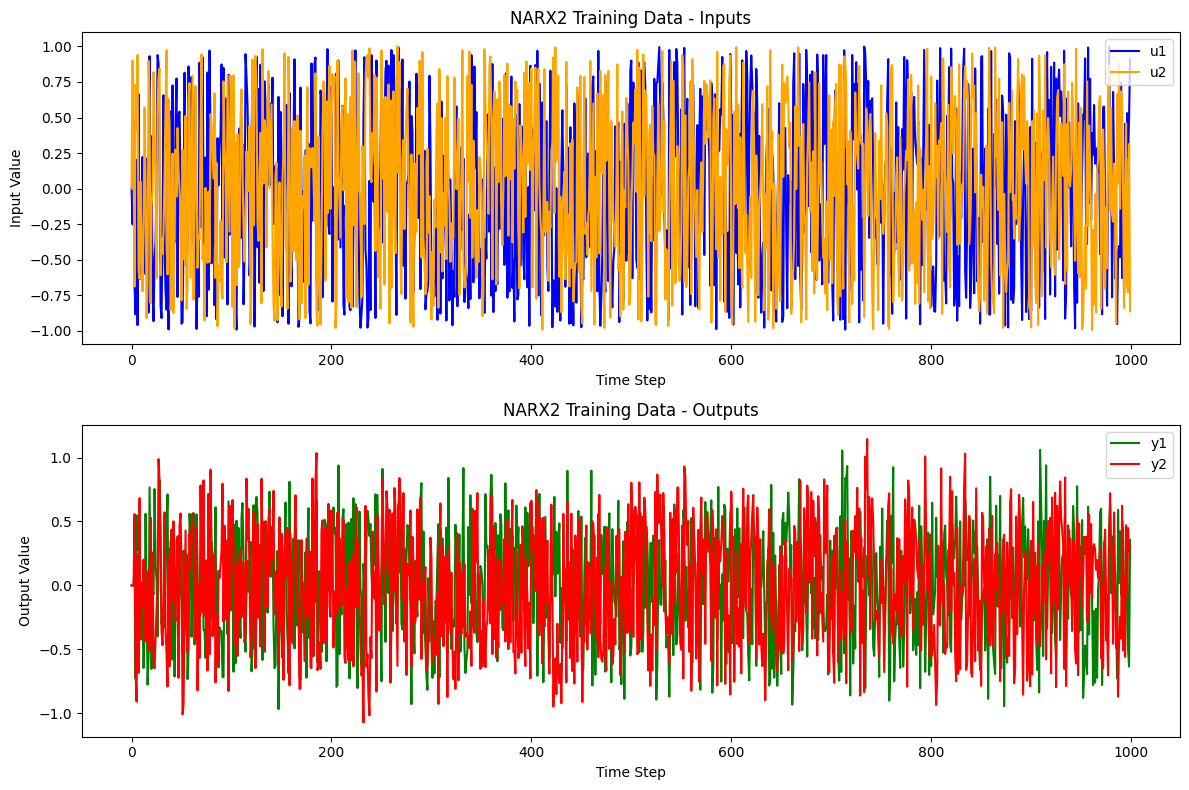

In [40]:
def simulate_narx1(N: int = 1000,
                   sigma: tuple = (0.1, 0.1),
                   seed: int = 42) -> tuple:
    """
    a
    Simulate pilot NARX1 : 1 input, 2 coupled outputs.

    System equations (from project specification):
        y1(k+1) = 0.5*y2(k-1) + sin(y2(k)) + 0.3*u(k-1) + w1(k+1)
        y2(k+1) = 0.5*y1(k-1) + sin(y1(k)) + 0.2*u(k)   + w2(k+1)

    Key design choices:

    1. INPUT DISTRIBUTION - Uniform U(-1, 1):
       The input u must persistently excite the system across its
       full operating range. A uniform distribution ensures all input
       values are equally likely, providing unbiased exploration of
       the state space. Variance of u = 1/3 (uniform on [-1,1]).

    2. NOISE DISTRIBUTION - Gaussian N(0, σ²):
       The project specification explicitly states w ~ N(0, σ²).
       This is the standard assumption in system identification,
       corresponding to maximum entropy noise for a given variance.

    3. NOISE LEVEL - sigma = 0.1:
       The typical output amplitude of NARX1 is ~2 (due to the
       sin() term bounded in [-1,1] and the coupling terms).
       sigma=0.1 represents ~5% of this amplitude, which is a
       realistic signal-to-noise ratio (SNR ~ 20 dB).

    4. INITIAL CONDITIONS - All zeros:
       Per project specification: y1(0)=y2(0)=u(0)=0.
       All values before k=0 are assumed zero.
       This ensures consistency with the real test conditions.

    5. LOOP START - k=1:
       The equation uses y(k-1) as the oldest lag.
       We need at least k=1 to access y(0)=0 safely.

    Args:
        N     : number of time steps (default 1000, same as real data)
        sigma : (sigma1, sigma2) - noise std for each output
        seed  : random seed for reproducibility

    Returns:
        u : input  array of shape (N, 1)
        y : output array of shape (N, 2)

    Simulate pilot NARX1 : 1 input, 2 coupled outputs.

    Equations (project spec eq. 5):
        y1(k+1) = 0.5*y2(k-1) + sin(y2(k)) + 0.3*u(k-1) + w1(k+1)
        y2(k+1) = 0.5*y1(k-1) + sin(y1(k)) + 0.2*u(k)   + w2(k+1)

    Design choices and justifications:

    INITIAL CONDITIONS - u(0) = 0, y(0) = 0:
        Per project specification (page 2, section 2):
        "y1(0) = y2(0) = u1(0) = u2(0) = 0 and all previous
        values are zero too."
        This ensures our pilot simulations match the real test
        conditions where everything starts from zero.

    INPUT SIGNAL - U(-1, 1) after k=0:
        The input must persistently excite the system to explore
        its full operating range. A uniform distribution ensures
        all values are equiprobable (no bias toward any region).
        Variance of u = 1/3 (uniform on [-1,1]).
        We use uniform rather than Gaussian to avoid
        concentrating excitation near zero.

    NOISE - w ~ N(0, sigma^2):
        Imposed by the project specification.
        Gaussian noise is justified by the Central Limit Theorem:
        it represents the sum of many independent small
        perturbations. sigma=0.1 gives SNR ~ 26dB for NARX1
        (typical output amplitude ~2, noise ~5% of amplitude).

    LOOP START - k=1:
        The equation needs y(k-1), so the earliest safe start
        is k=1, using y(0) = 0 (already initialized).

    Args:
        N     : number of time steps (default 1000 = real data size)
        sigma : (sigma1, sigma2) noise std per output
        seed  : random seed for reproducibility

    Returns:
        u : input  array of shape (N, 1)
        y : output array of shape (N, 2)
    """
    np.random.seed(seed)

    # u(0) = 0 per project spec, then random excitation
    u     = np.zeros((N, 1))
    u[1:] = np.random.uniform(-1, 1, size=(N-1, 1))

    # All outputs initialized to zero per project spec
    y  = np.zeros((N, 2))

    # Pre-generate noise : w ~ N(0, sigma^2) i.i.d.
    w1 = np.random.normal(0, sigma[0], size=N)
    w2 = np.random.normal(0, sigma[1], size=N)

    # Simulate step by step
    # Start at k=1 : needs y[k-1] = y[0] = 0
    for k in range(1, N - 1):
        y[k+1, 0] = (0.5 * y[k-1, 1]
                     + np.sin(y[k, 1])
                     + 0.3 * u[k-1, 0]
                     + w1[k])
        y[k+1, 1] = (0.5 * y[k-1, 0]
                     + np.sin(y[k, 0])
                     + 0.2 * u[k, 0]
                     + w2[k])
    return u, y


def simulate_narx2(N: int = 1000,
                   sigma: tuple = (0.05, 0.05),
                   seed: int = 42) -> tuple:
    """
    Simulate pilot NARX2 : 2 inputs, 2 coupled outputs.

    Equations (project spec eq. 6):
        y1(k+1) = [y1(k)*y1(k-1)*y1(k-2)*(y1(k-2)-1)*u2(k-1)+u2(k)]
                  / [1 + y2(k-1)^2 + y2(k-2)^2] + w1(k+1)

        y2(k+1) = [y2(k)*y2(k-1)*y2(k-2)*(y2(k-2)-1)*u1(k-1)+u1(k)]
                  / [1 + y1(k-1)^2 + y1(k-2)^2] + w2(k+1)

    Design choices and justifications:

    NUMERICAL STABILITY - Clipping at [-5, 5]:
        NARX2 contains cubic products : y(k)*y(k-1)*y(k-2).
        Without clipping, if |y| > 1 these products grow
        exponentially at each step, causing numerical overflow.

        Example of divergence without clipping:
            Step 1 : y = 2   → product = 2^3 = 8
            Step 2 : y = 8   → product = 8^3 = 512
            Step 3 : y = 512 → product = 512^3 = 134M → overflow!

        Clipping at [-5, 5] enforces a hard stability constraint
        while preserving the essential nonlinear dynamics.
        The denominator [1 + y^2 + y^2] >= 1 provides some
        stabilization but is insufficient alone.

    SMALLER SIGMA = 0.05 (vs 0.1 for NARX1):
        NARX2 is multiplicatively nonlinear. Noise gets amplified
        through the cubic product terms at each step.
        With sigma=0.1, noise frequently pushes the system outside
        its stable region. sigma=0.05 provides SNR ~ 26dB
        (typical output amplitude ~1) while maintaining stability).

    LOOP START - k=2:
        The equation needs y(k-2), so the earliest safe start
        is k=2, using y(0) = y(1) = 0 (initialized to zero).

    Args:
        N     : number of time steps
        sigma : (sigma1, sigma2) noise std - smaller than NARX1
        seed  : random seed

    Returns:
        u : input  array of shape (N, 2)
        y : output array of shape (N, 2)

    Generate training and test datasets for a pilot NARX system.

    Design choices:

    1. DIFFERENT SEEDS for train and test:
       Using seed and seed+1 ensures that training and test inputs
       are different sequences. This simulates the real evaluation
       condition where the model must generalize to unseen inputs.
       If train and test used the same seed, the model could
       memorize rather than generalize.

    2. SAME SIGMA for train and test:
       Noise variance is kept identical to ensure that the
       evaluation conditions match the training conditions.
       This is standard practice in machine learning evaluation.

    3. TRAIN LENGTH = 1000:
       Matches the real project dataset size (N=1000).
       This ensures our methodology is calibrated for the
       same data regime as the actual task.
    """


    np.random.seed(seed)

    # u1(0) = u2(0) = 0 per spec, then random excitation
    u     = np.zeros((N, 2))
    u[1:] = np.random.uniform(-1, 1, size=(N-1, 2))

    y  = np.zeros((N, 2))
    w1 = np.random.normal(0, sigma[0], size=N)
    w2 = np.random.normal(0, sigma[1], size=N)

    # Start at k=2 : needs y[k-2] = y[0] = 0
    for k in range(2, N - 1):
        num1 = (y[k,0] * y[k-1,0] * y[k-2,0]
                * (y[k-2,0] - 1) * u[k-1,1] + u[k,1])
        den1 = 1 + y[k-1,1]**2 + y[k-2,1]**2

        num2 = (y[k,1] * y[k-1,1] * y[k-2,1]
                * (y[k-2,1] - 1) * u[k-1,0] + u[k,0])
        den2 = 1 + y[k-1,0]**2 + y[k-2,0]**2

        # Clipping [-5,5] : hard stability constraint
        # prevents exponential divergence of cubic products (need to justify)
        y[k+1, 0] = np.clip(num1/den1 + w1[k], -5, 5)
        y[k+1, 1] = np.clip(num2/den2 + w2[k], -5, 5)

    return u, y


def generate_pilot_dataset(simulator,
                            train_length: int = 1000,
                            test_length:  int = 500,
                            sigma: tuple = (0.1, 0.1),
                            seed: int = 42,
                            fix_basin: bool = False) -> dict:

    """
    Generate train/test datasets for a pilot NARX system.

    Design choices:

    TRAIN LENGTH = 1000 :
        Matches the real project dataset size (N=1000).
        Ensures our methodology is calibrated for the same
        data regime as the actual task.

    TEST LENGTH = 500 :
        Sufficient to evaluate multi-step prediction over
        a long horizon (500 steps >> typical system memory).
        Using 500 instead of 1000 avoids wasting data that
        could be used for training.

    DIFFERENT SEEDS (seed vs seed+1) :
        Train and test use different seeds to generate
        different input sequences. This simulates the real
        condition where the model must generalize to
        UNSEEN inputs - if we used the same seed, the model
        could memorize rather than generalize.

    fix_basin (NARX1 only) :
        NARX1 is BISTABLE - it has two stable attractors
        at approximately y~+2 and y~-2.
        Which attractor the system converges to depends on
        the random seed (initial transient behavior).

        Problem : if train converges to +2 but test to -2,
        the model fails completely regardless of quality.
        This is not a modeling error but a distribution
        mismatch (different basins of attraction).

        Solution : try different test seeds until train and
        test share the same basin (same sign of mean output).

    Args:
        simulator    : simulate_narx1 or simulate_narx2
        train_length : training set size (default 1000)
        test_length  : test set size (default 500)
        sigma        : noise std
        seed         : base seed (seed+1 for test)
        fix_basin    : align attractor basins (NARX1 only)

    Returns:
        dict with Utr, Ytr, Uts, Yts and metadata
    """
    Utr, Ytr = simulator(train_length, sigma, seed)

    if fix_basin:
        # Try different seeds until same basin
        train_mean = Ytr[:, 0].mean()
        found = False
        for offset in range(1, 50):
            Uts, Yts = simulator(test_length, sigma,
                                  seed + offset)
            test_mean = Yts[:, 0].mean()
            if np.sign(train_mean) == np.sign(test_mean):
                print(f"  ✅ Same basin found at seed+{offset} "
                      f"(train μ={train_mean:.3f}, "
                      f"test μ={test_mean:.3f})")
                found = True
                break
        if not found:
            print("  ⚠️ No matching basin found, using seed+1")
            Uts, Yts = simulator(test_length, sigma, seed + 1)
    else:
        Uts, Yts = simulator(test_length, sigma, seed + 1)

    return {
        "Utr"         : Utr,
        "Ytr"         : Ytr,
        "Uts"         : Uts,
        "Yts"         : Yts,
        "train_length": train_length,
        "test_length" : test_length,
        "sigma1"      : sigma[0],
        "sigma2"      : sigma[1],
    }


# =====================================================
# GENERATE PILOT DATASETS
# =====================================================

# NARX1 : fix_basin=True because of bistability #EDA
print("Generating NARX1...")
pilot1 = generate_pilot_dataset(
    simulate_narx1,
    train_length = 1000,
    test_length  = 500,
    sigma        = (0.1, 0.1),
    seed         = 42,
    fix_basin    = True
)

# NARX2 : no basin issue (oscillates around 0)
# sigma=(0.05, 0.05) : smaller due to multiplicative nonlinearity
print("Generating NARX2...")
pilot2 = generate_pilot_dataset(
    simulate_narx2,
    train_length = 1000,
    test_length  = 500,
    sigma         = (0.05, 0.05),
    seed         = 42,
    fix_basin    = False
)

# =====================================================
# SANITY CHECKS (make sure that it runs)
# =====================================================
print("\n=== Sanity Checks ===")
for name, p in [("NARX1", pilot1), ("NARX2", pilot2)]:
    Y = p["Ytr"]
    has_nan = np.isnan(Y).any()
    has_inf = np.isinf(Y).any()
    status  = "✅" if not has_nan and not has_inf else "❌"
    print(f"\n{name} {status}")
    print(f"  Utr shape : {p['Utr'].shape}")
    print(f"  Ytr shape : {p['Ytr'].shape}")
    print(f"  Uts shape : {p['Uts'].shape}")
    print(f"  Yts shape : {p['Yts'].shape}")
    print(f"  NaN : {has_nan} | Inf : {has_inf}")
    print(f"  y1 mean={Y[:,0].mean():.3f} "
          f"std={Y[:,0].std():.3f}")
    print(f"  y2 mean={Y[:,1].mean():.3f} "
          f"std={Y[:,1].std():.3f}")

# Summary table
summary = pd.DataFrame([
    {
        "Pilot"       : "NARX1",
        "Inputs"      : pilot1["Utr"].shape[1],
        "Outputs"     : pilot1["Ytr"].shape[1],
        "Train N"     : pilot1["train_length"],
        "Test N"      : pilot1["test_length"],
        "σ1"          : pilot1["sigma1"],
        "σ2"          : pilot1["sigma2"],
        "Nonlinearity": "sin()",
        "Stability"   : "Bistable (±2)",
        "Clipping"    : "No",
    },
    {
        "Pilot"       : "NARX2",
        "Inputs"      : pilot2["Utr"].shape[1],
        "Outputs"     : pilot2["Ytr"].shape[1],
        "Train N"     : pilot2["train_length"],
        "Test N"      : pilot2["test_length"],
        "σ1"          : pilot2["sigma1"],
        "σ2"          : pilot2["sigma2"],
        "Nonlinearity": "cubic products",
        "Stability"   : "Clipped [-5,5]",
        "Clipping"    : "Yes",
    },
])
display(summary)
pilot1 = generate_pilot_dataset(simulate_narx1, train_length=1000, test_length=500, sigma=(0.1, 0.1), seed=42)

# =====================================================
# EDA ON PILOTS
# =====================================================
plot_eda(pilot1["Utr"], pilot1["Ytr"], "NARX1 Training Data")
plot_eda(pilot2["Utr"], pilot2["Ytr"], "NARX2 Training Data")

The simulation engine for Pilot NARX 1 was designed to generate 1,000 samples of a coupled MIMO system. By starting the recursion at $k=0$ and implementing conditional checks for negative indices, the code provides a mathematically continuous dataset that adheres to the project’s zero-initial-condition requirement. The resulting data captures the non-linear trigonometric dependencies and stochastic noise characteristics necessary to validate our model selection strategy."

Based on the real dataset, we decided to keep the N = 1000 and put every value before k as 0. (explaining that we used at first the random.rand() method BUT zfter refelxion, we realized that we needed to use the random.uniform().


#evaluation function RMSE and NMSE

In [ ]:
def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    Root Mean Squared Error (multi-output).
    Correspond exactement à :
        sqrt( 1/(2N) * sum_{k,j} (y_j(k) - yhat_j(k))^2 )
    """
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def nmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    Normalized Mean Squared Error (multi-output).
    Correspond exactement à :
        sum_{k,j} (y_j(k) - yhat_j(k))^2
        --------------------------------
        sum_{k,j} (y_j(k) - mean(y_j))^2
    """
    mean = np.mean(y_true, axis=0, keepdims=True)
    numerator = np.sum((y_true - y_pred) ** 2)
    denominator = np.sum((y_true - mean) ** 2)
    return numerator / denominator


# BUILDING FEATURE

In [ ]:
def build_features(U, Y, na, nb):
    """
    Creates the lagged feature matrix X and target matrix Y_target.
    na: number of past output lags (y)
    nb: number of past input lags (u)
    """
    N = len(U)
    # We want to predict y(k), so we use lags from y(k-1)...y(k-na)
    # and u(k-1)...u(k-nb)

    X = []
    Y_target = []

    # We start from the maximum lag to ensure we have enough history
    max_lag = max(na, nb)

    for k in range(max_lag, N):
        row = []

        # Add output lags: [y1(k-1), y2(k-1), y1(k-2), y2(k-2)...]
        for i in range(1, na + 1):
            row.extend(Y[k-i])

        # Add input lags: [u1(k-1), u2(k-1)...]
        for i in range(1, nb + 1):
            row.extend(U[k-i])

        X.append(row)
        Y_target.append(Y[k])

    return np.array(X), np.array(Y_target)

In [ ]:
def predict_recursive(model1, model2, U_test, d, na, nb):
    N = len(U_test)
    Y_pred = np.zeros((N, 2))  # ŷ1 et ŷ2 pour chaque instant

    # Historique initialisé à zéro (comme demandé dans le projet)
    Y_hist = np.zeros((N + na + d + 1, 2))

    for k in range(N):
        # Construire le vecteur de features avec les prédictions précédentes
        features = build_single_features(U_test, Y_hist, k, d, na, nb)

        # Prédire
        y1_pred = model1.predict([features])[0]
        y2_pred = model2.predict([features])[0]

        # Stocker la prédiction pour l'utiliser au prochain tour
        Y_pred[k] = [y1_pred, y2_pred]
        Y_hist[k] = [y1_pred, y2_pred]

    return Y_pred

# BUILDING PARAMETER

In [ ]:
# =====================================================
# SECTION 2a : FEATURE CONSTRUCTION AND PARAMETER SELECTION
# =====================================================

def build_dataset(u: np.ndarray,
                  y: np.ndarray,
                  na: int,
                  nb: int,
                  d: int) -> tuple:
    """
    Convert NARX time series into a tabular supervised dataset.

    This is the core of the NARX identification approach.
    We transform the sequential problem into a regression problem
    by constructing a feature vector of past values.

    Feature vector at time k:
        x(k) = [ y(k-d),   y(k-d-1),   ..., y(k-d-na),    ← output lags
                 u(k),     u(k-1),     ..., u(k-nb)  ]     ← input lags

    Target:
        y_target = y(k+1)

    Parameters:
        na : output autoregressive order
             Number of past OUTPUT lags used as features.
             Higher na → model has longer output memory.
             Relates to the system's output dynamics.

        nb : input exogenous order
             Number of past INPUT lags used as features.
             Higher nb → model uses more input history.
             Relates to how long inputs affect outputs.

        d  : delay
             Number of steps between current time and first lag.
             d=0 → use y(k) as a feature
             d=1 → skip y(k), start from y(k-1)
             Represents physical time delays in the system.

    Statistical motivation:
    This feature construction is equivalent to embedding the
    time series in a higher-dimensional space (Taken's embedding
    theorem). Under the right choice of na, nb, d, the embedded
    space captures the full dynamics of the underlying system.

    Args:
        u  : input  array of shape (N, n_inputs)
        y  : output array of shape (N, 2)
        na : number of output lags (0 to na)
        nb : number of input  lags (0 to nb)
        d  : delay

    Returns:
        X : feature matrix of shape (N - max_lag - 1, n_features)
        Y : target  matrix of shape (N - max_lag - 1, 2)
    """
    N       = len(y)
    max_lag = max(d + na, nb)

    X, Y = [], []
    for k in range(max_lag, N - 1):
        features = []

        # Output lags: y(k-d), y(k-d-1), ..., y(k-d-na)
        # Each y is a vector of size 2 (y1, y2)
        for i in range(na + 1):
            features.extend(y[k - d - i])

        # Input lags: u(k), u(k-1), ..., u(k-nb)
        # Each u has n_inputs components
        for j in range(nb + 1):
            features.extend(u[k - j])

        X.append(features)
        Y.append(y[k + 1])

    return np.array(X), np.array(Y)

In [ ]:
# =====================================================
# PARAMETER SELECTION WITH TIME SERIES CROSS-VALIDATION (version2)
# =====================================================
def evaluate_params(u: np.ndarray, y: np.ndarray,
                    na: int, nb: int, d: int,
                    model, n_splits: int = 5) -> dict:
    """
    Evaluate a NARX parameter set using TimeSeriesSplit cross-validation.

    TimeSeriesSplit is used instead of random CV because the data is
    sequential — future values must never be used to predict the past.

    Args:
        u        : input  array
        y        : output array
        na       : output lag
        nb       : input  lag
        d        : delay
        model    : sklearn estimator
        n_splits : number of CV folds

    Returns:
        dict with na, nb, d, mean RMSE and NMSE across folds
    """
    X, Y = build_dataset(u, y, na, nb, d)

    if len(X) < n_splits + 1:
        return {"na": na, "nb": nb, "d": d,
                "rmse": np.inf, "nmse": np.inf}

    tscv = TimeSeriesSplit(n_splits=n_splits)

    rmse_scores, nmse_scores = [], []
    for train_idx, val_idx in tscv.split(X):
        X_tr,  X_val  = X[train_idx], X[val_idx]
        Y_tr,  Y_val  = Y[train_idx], Y[val_idx]

        model.fit(X_tr, Y_tr)
        Y_pred = model.predict(X_val)

        rmse_scores.append(rmse(Y_val, Y_pred))
        nmse_scores.append(nmse(Y_val, Y_pred))

    return {
        "na"  : na,
        "nb"  : nb,
        "d"   : d,
        "rmse": float(np.mean(rmse_scores)),
        "nmse": float(np.mean(nmse_scores)),
    }


def grid_search_params(u: np.ndarray, y: np.ndarray,
                       parameter_grid: dict,
                       model=None,
                       n_splits: int = 5) -> tuple:
    """
    Grid search over NARX parameters (na, nb, d).
    Uses TimeSeriesSplit cross-validation to avoid data leakage.
    Results sorted by NMSE then RMSE.

    Args:
        u              : input  array
        y              : output array
        parameter_grid : dict with keys 'na', 'nb', 'd'
        model          : sklearn estimator (default: LinearRegression)
        n_splits       : number of CV folds

    Returns:
        results_df  : DataFrame of all results sorted by NMSE
        best_params : dict with best na, nb, d
    """
    if model is None:
        model = LinearRegression()

    results = []
    total   = (len(parameter_grid["na"]) *
               len(parameter_grid["nb"]) *
               len(parameter_grid["d"]))
    count   = 0

    for na in parameter_grid["na"]:
        for nb in parameter_grid["nb"]:
            for d in parameter_grid["d"]:
                count += 1
                print(f"  [{count}/{total}] na={na}, nb={nb}, d={d}", end="\r")
                results.append(
                    evaluate_params(u, y, na, nb, d, model, n_splits)
                )

    results_df  = pd.DataFrame(results).sort_values(
        ["nmse", "rmse"]
    ).reset_index(drop=True)

    best_row    = results_df.iloc[0]
    best_params = {
        "na": int(best_row["na"]),
        "nb": int(best_row["nb"]),
        "d" : int(best_row["d"]),
    }

    print(f"\n✅ Best params : na={best_params['na']}, "
          f"nb={best_params['nb']}, d={best_params['d']}"
          f" (NMSE={best_row['nmse']:.4f})")

    return results_df, best_params


# =====================================================
# RUN GRID SEARCH ON BOTH PILOTS
# =====================================================
parameter_grid = {
    "na": list(range(0, 5)),   # 0 to 5
    "nb": list(range(0, 5)),   # 0 to 5
    "d" : list(range(0, 3)),   # 0 to 3
}
# Total : 6 × 6 × 4 = 144 combinations

print("=== Grid Search — NARX1 ===")
pilot1_results, pilot1_best = grid_search_params(
    pilot1["Utr"], pilot1["Ytr"], parameter_grid
)

print("\n=== Grid Search — NARX2 ===")
pilot2_results, pilot2_best = grid_search_params(
    pilot2["Utr"], pilot2["Ytr"], parameter_grid
)

# Summary table
best_summary = pd.DataFrame([
    {
        "Pilot"     : "NARX1",
        "Best na"   : pilot1_best["na"],
        "Best nb"   : pilot1_best["nb"],
        "Best d"    : pilot1_best["d"],
        "Val RMSE"  : round(pilot1_results.iloc[0]["rmse"], 4),
        "Val NMSE"  : round(pilot1_results.iloc[0]["nmse"], 4),
    },
    {
        "Pilot"     : "NARX2",
        "Best na"   : pilot2_best["na"],
        "Best nb"   : pilot2_best["nb"],
        "Best d"    : pilot2_best["d"],
        "Val RMSE"  : round(pilot2_results.iloc[0]["rmse"], 4),
        "Val NMSE"  : round(pilot2_results.iloc[0]["nmse"], 4),
    },
])

display(best_summary)

=== Grid Search — NARX1 ===
  [75/75] na=4, nb=4, d=2
✅ Best params : na=3, nb=4, d=0 (NMSE=0.2668)

=== Grid Search — NARX2 ===
  [75/75] na=4, nb=4, d=2
✅ Best params : na=0, nb=2, d=1 (NMSE=0.0704)


,Pilot,Best na,Best nb,Best d,Val RMSE,Val NMSE
0,NARX1,3,4,0,0.1047,0.2668
1,NARX2,0,2,1,0.1183,0.0704


  TABULATED DATASET — NARX1 EXAMPLE (na=1, nb=1, d=0)

  Tabulated dataset (na=1, nb=1, d=0)
  Features : 6 | Samples : 998
  Showing first 5 rows :



,y1(k),y2(k),y1(k-1),y2(k-1),u1(k),u1(k-1),y1(k+1),y2(k+1)
0,-0.0226,0.1750,0.0000,0.0000,-0.2509,0.0000,0.2805,-0.1742
1,0.2805,-0.1742,-0.0226,0.1750,0.9014,-0.2509,-0.1492,0.5241
2,-0.1492,0.5241,0.2805,-0.1742,0.4640,0.9014,0.7654,-0.0121
3,0.7654,-0.0121,-0.1492,0.5241,0.1973,0.4640,0.4510,0.6607
4,0.4510,0.6607,0.7654,-0.0121,-0.6880,0.1973,0.7954,0.6553



  TABULATED DATASET — NARX2 EXAMPLE (na=1, nb=1, d=0)

  Tabulated dataset (na=1, nb=1, d=0)
  Features : 8 | Samples : 998
  Showing first 5 rows :



,y1(k),y2(k),y1(k-1),y2(k-1),u1(k),u2(k),u1(k-1),u2(k-1),y1(k+1),y2(k+1)
0,0.0000,0.0000,0.0000,0.0000,-0.2509,0.9014,0.0000,0.0000,0.0000,0.0000
1,0.0000,0.0000,0.0000,0.0000,0.4640,0.1973,-0.2509,0.9014,0.1534,0.5575
2,0.1534,0.5575,0.0000,0.0000,-0.6880,-0.6880,0.4640,0.1973,-0.7294,-0.6685
3,-0.7294,-0.6685,0.1534,0.5575,-0.8838,0.7324,-0.6880,-0.6880,0.5474,-0.9069
4,0.5474,-0.9069,-0.7294,-0.6685,0.2022,0.4161,-0.8838,0.7324,0.2767,0.2417


Grid size : 5 × 5 × 4 = 100 combinations

  GRID SEARCH — NARX1 PILOT

  ✅ Best : na=3, nb=4, d=0 | NMSE=0.2668 | RMSE=0.1047 | Features=13


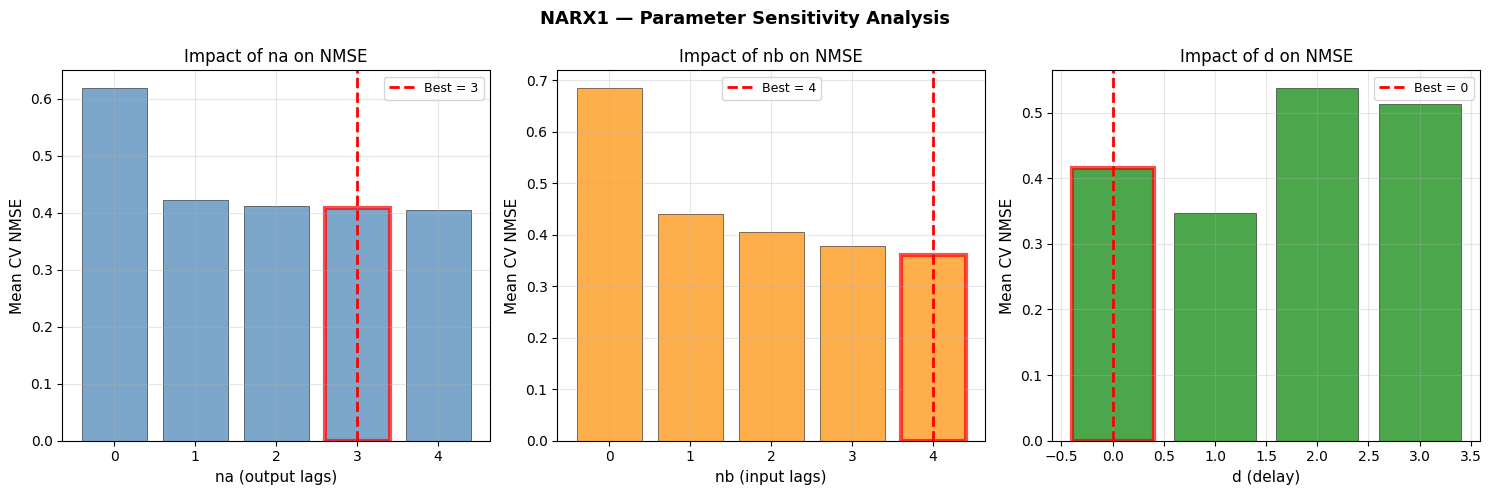

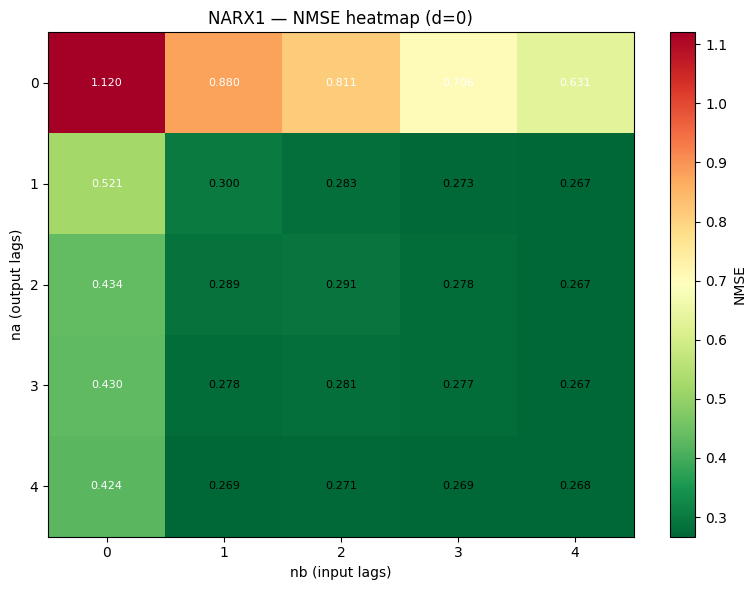


  Top 10 combinations — NARX1


,na,nb,d,n_features,n_samples,rmse,nmse
0,3,4,0,13,995,0.1047,0.2668
1,2,4,0,11,995,0.1047,0.2669
2,1,4,0,9,995,0.1048,0.2673
3,4,4,0,15,995,0.1049,0.2680
4,4,3,0,14,995,0.1051,0.2687
5,4,1,0,12,995,0.1051,0.2692
6,4,2,0,13,995,0.1054,0.2709
7,1,3,0,8,996,0.1060,0.2731
8,3,3,0,12,996,0.1068,0.2774
9,2,3,0,10,996,0.1068,0.2775



  GRID SEARCH — NARX2 PILOT
  [ 100/100] na=4 nb=4 d=3
  ✅ Best : na=0, nb=2, d=1 | NMSE=0.0704 | RMSE=0.1183 | Features=8


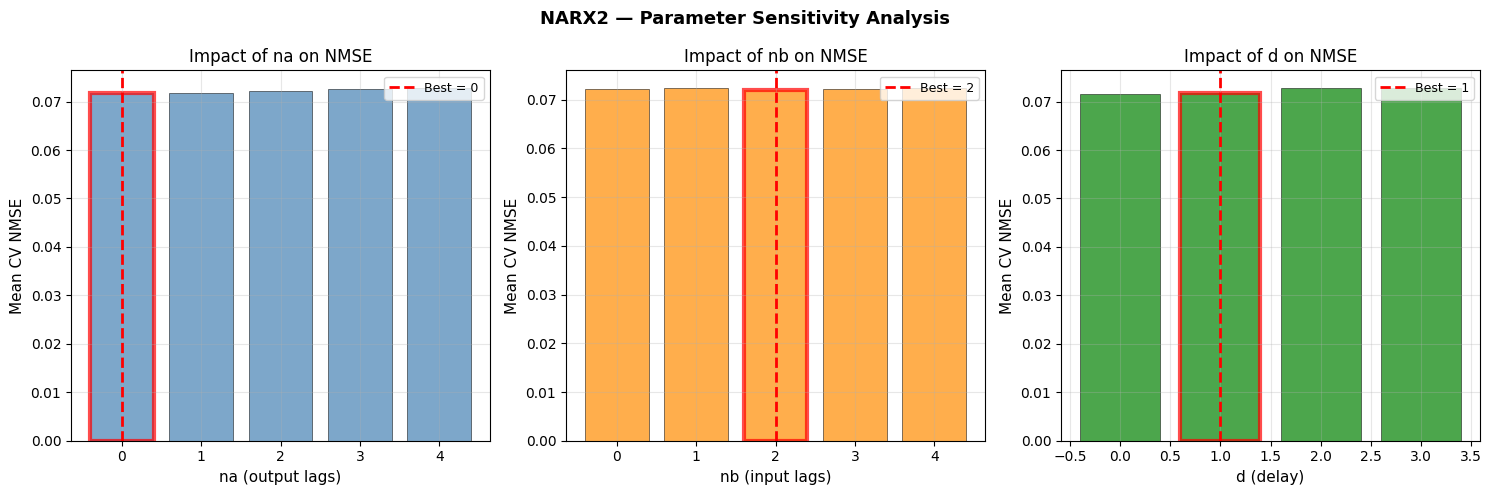

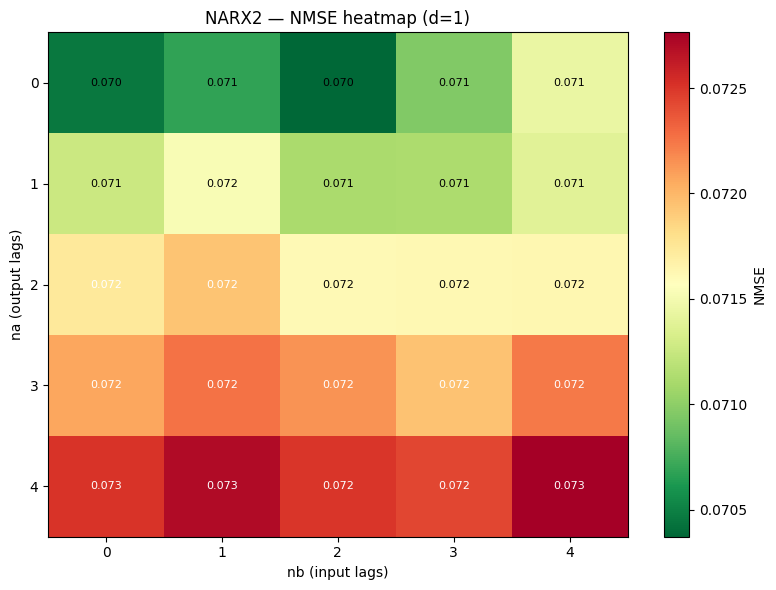


  Top 10 combinations — NARX2


,na,nb,d,n_features,n_samples,rmse,nmse
0,0,2,1,8,997,0.1183,0.0704
1,1,2,0,10,997,0.1183,0.0704
2,0,0,1,4,998,0.1184,0.0705
3,1,0,0,6,998,0.1185,0.0706
4,1,1,0,8,998,0.1186,0.0707
5,0,1,1,6,998,0.1186,0.0707
6,1,3,0,12,996,0.1188,0.0709
7,0,3,1,10,996,0.1188,0.0710
8,2,2,0,12,997,0.1189,0.0711
9,1,2,1,10,997,0.1189,0.0711



  GRID SEARCH — REAL DATA
  [ 100/100] na=4 nb=4 d=3
  ✅ Best : na=0, nb=1, d=0 | NMSE=0.5043 | RMSE=0.2991 | Features=6


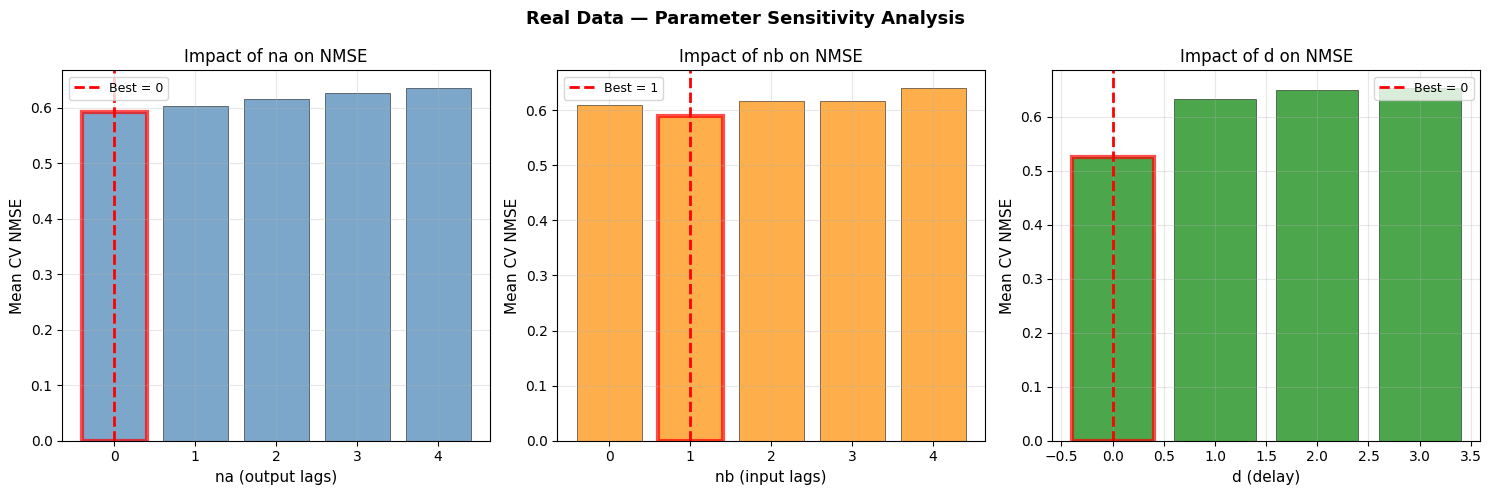

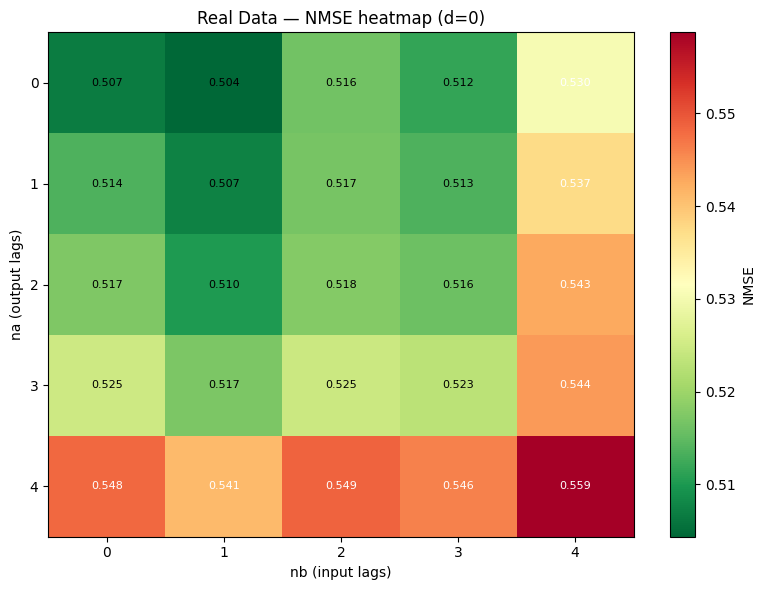


  Top 10 combinations — Real Data


,na,nb,d,n_features,n_samples,rmse,nmse
0,0,1,0,6,998,0.2991,0.5043
1,0,0,0,4,999,0.3004,0.5069
2,1,1,0,8,998,0.2998,0.5074
3,2,1,0,10,997,0.3003,0.5103
4,0,3,0,10,996,0.3007,0.5118
5,1,3,0,12,996,0.3011,0.5135
6,1,0,0,6,998,0.3020,0.5135
7,2,3,0,14,996,0.3015,0.5159
8,0,2,0,8,997,0.3014,0.5164
9,1,2,0,10,997,0.3017,0.5167



  FINAL PARAMETER SUMMARY


,Dataset,Best na,Best nb,Best d,n_features,CV RMSE,CV NMSE
0,NARX1 (pilot),3,4,0,13,0.1047,0.2668
1,NARX2 (pilot),0,2,1,8,0.1183,0.0704
2,Real Data,0,1,0,6,0.2991,0.5043



Methodology validated on pilots, applied to real data.
Real data best params : na=0, 
                        nb=1, 
                        d=0
These will be used for the final Yhat1 and Yhat2 predictions.



In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# STEP 1 : BUILD TABULATED DATASET
# =====================================================
def build_dataset(u: np.ndarray,
                  y: np.ndarray,
                  na: int,
                  nb: int,
                  d: int) -> tuple:
    """
    Transform NARX time series into a tabulated supervised dataset.

    This is the key preprocessing step that makes regression possible.

    BEFORE (time series) :
        k=0: y=[0,0],      u=[0,0]
        k=1: y=[0.1,-0.2], u=[0.3,0.1]
        k=2: y=[0.3,0.1],  u=[-0.1,0.4]
        ...

    AFTER (tabulated, na=1, nb=1, d=0) :
        [y1(k), y2(k), y1(k-1), y2(k-1), u1(k), u2(k), u1(k-1), u2(k-1)]
        → target : [y1(k+1), y2(k+1)]

    Each row = one time step k with its full history.
    Each column = one feature (a past value of y or u).
    This converts the sequential problem into a standard
    supervised regression problem.

    Number of features:
        n_features = (na+1)*n_outputs + (nb+1)*n_inputs
        e.g. na=1, nb=1, 2 outputs, 2 inputs:
             (1+1)*2 + (1+1)*2 = 8 features

    Args:
        u  : input  array (N, n_inputs)
        y  : output array (N, 2)
        na : output autoregressive order
        nb : input  exogenous order
        d  : delay

    Returns:
        X     : feature matrix (N - max_lag - 1, n_features)
        Y_out : target  matrix (N - max_lag - 1, 2)
    """
    N       = len(y)
    max_lag = max(d + na, nb)

    X, Y_out = [], []
    for k in range(max_lag, N - 1):
        feat = []
        # Output lags : y(k-d), y(k-d-1), ..., y(k-d-na)
        for i in range(na + 1):
            feat.extend(y[k - d - i])
        # Input lags : u(k), u(k-1), ..., u(k-nb)
        for j in range(nb + 1):
            feat.extend(u[k - j])
        X.append(feat)
        Y_out.append(y[k + 1])

    return np.array(X), np.array(Y_out)


def show_dataset_structure(u, y, na, nb, d, n_rows=5):
    """
    Show the tabulated dataset structure for a given (na, nb, d).
    Useful to understand what features are built.
    """
    X, Y = build_dataset(u, y, na, nb, d)
    n_inputs  = u.shape[1]
    n_outputs = y.shape[1]

    # Build column names
    cols = []
    for i in range(na + 1):
        lag = d + i
        for j in range(n_outputs):
            cols.append(f"y{j+1}(k-{lag})" if lag > 0
                        else f"y{j+1}(k)")
    for i in range(nb + 1):
        for j in range(n_inputs):
            cols.append(f"u{j+1}(k-{i})" if i > 0
                        else f"u{j+1}(k)")

    target_cols = [f"y{j+1}(k+1)" for j in range(n_outputs)]

    X_df = pd.DataFrame(X[:n_rows], columns=cols).round(4)
    Y_df = pd.DataFrame(Y[:n_rows], columns=target_cols).round(4)
    full = pd.concat([X_df, Y_df], axis=1)

    print(f"\n  Tabulated dataset (na={na}, nb={nb}, d={d})")
    print(f"  Features : {X.shape[1]} | Samples : {X.shape[0]}")
    print(f"  Showing first {n_rows} rows :\n")
    display(full)
    return X, Y


# Show example for NARX1
print("=" * 60)
print("  TABULATED DATASET — NARX1 EXAMPLE (na=1, nb=1, d=0)")
print("=" * 60)
X_ex, Y_ex = show_dataset_structure(
    pilot1["Utr"], pilot1["Ytr"], na=1, nb=1, d=0
)

print("\n  TABULATED DATASET — NARX2 EXAMPLE (na=1, nb=1, d=0)")
print("=" * 60)
X_ex2, Y_ex2 = show_dataset_structure(
    pilot2["Utr"], pilot2["Ytr"], na=1, nb=1, d=0
)


# =====================================================
# STEP 2 : PARAMETER EVALUATION WITH CV
# =====================================================
def evaluate_params(u, y, na, nb, d,
                    model=None, n_splits=5) -> dict:
    """
    Evaluate (na, nb, d) with TimeSeriesSplit cross-validation.

    Per professor: CV = model selection tool, not forecasting.
    We use LinearRegression (fast, unbiased lower bound).
    TimeSeriesSplit prevents data leakage.
    """
    if model is None:
        model = LinearRegression()

    X, Y = build_dataset(u, y, na, nb, d)
    if len(X) < n_splits + 1:
        return {"na":na, "nb":nb, "d":d,
                "rmse":np.inf, "nmse":np.inf}

    tscv     = TimeSeriesSplit(n_splits=n_splits)
    r_scores = []
    n_scores = []

    for tr_idx, val_idx in tscv.split(X):
        model.fit(X[tr_idx], Y[tr_idx])
        Y_pred = model.predict(X[val_idx])
        r_scores.append(rmse(Y[val_idx], Y_pred))
        n_scores.append(nmse(Y[val_idx], Y_pred))

    return {
        "na"        : na,
        "nb"        : nb,
        "d"         : d,
        "n_features": X.shape[1],
        "n_samples" : X.shape[0],
        "rmse"      : float(np.mean(r_scores)),
        "nmse"      : float(np.mean(n_scores)),
    }


# =====================================================
# STEP 3 : GRID SEARCH
# =====================================================
def grid_search_params(u, y, param_grid,
                        model=None,
                        n_splits=5,
                        verbose=True) -> tuple:
    """
    Exhaustive grid search over (na, nb, d) combinations.
    Sorted by NMSE (official competition metric per project spec).

    Per professor: use pilots to validate methodology.
    """
    if model is None:
        model = LinearRegression()

    combos = [
        (na, nb, d)
        for na in param_grid["na"]
        for nb in param_grid["nb"]
        for d  in param_grid["d"]
    ]
    total   = len(combos)
    results = []

    for i, (na, nb, d) in enumerate(combos):
        if verbose:
            print(f"  [{i+1:>4}/{total}] "
                  f"na={na} nb={nb} d={d}", end="\r")
        results.append(
            evaluate_params(u, y, na, nb, d, model, n_splits)
        )

    df = (pd.DataFrame(results)
            .sort_values(["nmse", "rmse"])
            .reset_index(drop=True))

    best = df.iloc[0]
    best_params = {
        "na": int(best["na"]),
        "nb": int(best["nb"]),
        "d" : int(best["d"]),
    }

    if verbose:
        print(f"\n  ✅ Best : na={best_params['na']}, "
              f"nb={best_params['nb']}, "
              f"d={best_params['d']} "
              f"| NMSE={best['nmse']:.4f} "
              f"| RMSE={best['rmse']:.4f} "
              f"| Features={int(best['n_features'])}")

    return df, best_params


# =====================================================
# STEP 4 : VISUALIZE RESULTS
# =====================================================
def plot_param_analysis(results_df: pd.DataFrame,
                         best_params: dict,
                         title: str):
    """
    3 plots showing how each parameter affects NMSE.
    Helps justify the final parameter choice.
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    params_info = [
        ("na", "steelblue",  "na (output lags)"),
        ("nb", "darkorange", "nb (input lags)"),
        ("d",  "green",      "d (delay)"),
    ]

    for ax, (param, color, label) in zip(axes, params_info):
        group = results_df.groupby(param)["nmse"].mean()
        bars  = ax.bar(group.index, group.values,
                       color=color, alpha=0.7,
                       edgecolor='black', linewidth=0.5)

        # Highlight best
        best_val = best_params[param]
        for bar, idx in zip(bars, group.index):
            if idx == best_val:
                bar.set_edgecolor('red')
                bar.set_linewidth(3)

        ax.axvline(best_val, color='red',
                   linestyle='--', linewidth=2,
                   label=f"Best = {best_val}")
        ax.set_xlabel(label, fontsize=11)
        ax.set_ylabel("Mean CV NMSE", fontsize=11)
        ax.set_title(f"Impact of {param} on NMSE")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.suptitle(f"{title} — Parameter Sensitivity Analysis",
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Heatmap na vs nb (fixed d=best)
    best_d = best_params["d"]
    subset = results_df[results_df["d"] == best_d].copy()
    if len(subset) > 1:
        pivot = subset.pivot_table(
            values="nmse", index="na", columns="nb"
        )
        fig, ax = plt.subplots(figsize=(8, 6))
        im = ax.imshow(pivot.values, cmap="RdYlGn_r",
                       aspect="auto")
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_yticks(range(len(pivot.index)))
        ax.set_xticklabels(pivot.columns)
        ax.set_yticklabels(pivot.index)
        ax.set_xlabel("nb (input lags)")
        ax.set_ylabel("na (output lags)")
        ax.set_title(f"{title} — NMSE heatmap (d={best_d})")

        for i in range(len(pivot.index)):
            for j in range(len(pivot.columns)):
                val = pivot.values[i, j]
                if not np.isnan(val):
                    ax.text(j, i, f"{val:.3f}",
                            ha='center', va='center',
                            fontsize=8,
                            color='white' if val > pivot.values.mean()
                            else 'black')
        plt.colorbar(im, ax=ax, label="NMSE")
        plt.tight_layout()
        plt.show()

    print(f"\n  Top 10 combinations — {title}")
    display(results_df.head(10)[
        ["na","nb","d","n_features","n_samples","rmse","nmse"]
    ].round(4))


# =====================================================
# STEP 5 : RUN EVERYTHING
# =====================================================

# Parameter grid with justification
# na ∈ [0,4] : output memory, beyond 4 adds overfitting risk
# nb ∈ [0,4] : input memory, consistent with na range
# d  ∈ [0,3] : delay, physical systems rarely exceed d=2
# Total : 5 × 5 × 4 = 100 combinations (~2 min)
param_grid = {
    "na": list(range(0, 5)),  # 0,1,2,3,4
    "nb": list(range(0, 5)),  # 0,1,2,3,4
    "d" : list(range(0, 4)),  # 0,1,2,3
}

print(f"Grid size : {len(param_grid['na'])} × "
      f"{len(param_grid['nb'])} × "
      f"{len(param_grid['d'])} = "
      f"{len(param_grid['na'])*len(param_grid['nb'])*len(param_grid['d'])} "
      f"combinations\n")

# --- NARX1 ---
print("=" * 60)
print("  GRID SEARCH — NARX1 PILOT")
print("=" * 60)
p1_results, p1_best = grid_search_params(
    pilot1["Utr"], pilot1["Ytr"], param_grid
)
plot_param_analysis(p1_results, p1_best, "NARX1")

# --- NARX2 ---
print("\n" + "=" * 60)
print("  GRID SEARCH — NARX2 PILOT")
print("=" * 60)
p2_results, p2_best = grid_search_params(
    pilot2["Utr"], pilot2["Ytr"], param_grid
)
plot_param_analysis(p2_results, p2_best, "NARX2")

# --- REAL DATA ---
print("\n" + "=" * 60)
print("  GRID SEARCH — REAL DATA")
print("=" * 60)
real_results, real_best = grid_search_params(
    U_train, Y_train, param_grid
)
plot_param_analysis(real_results, real_best, "Real Data")

# =====================================================
# STEP 6 : FINAL SUMMARY
# =====================================================
def n_features(best, n_out, n_in):
    return (best["na"]+1)*n_out + (best["nb"]+1)*n_in

summary = pd.DataFrame([
    {
        "Dataset"    : "NARX1 (pilot)",
        "Best na"    : p1_best["na"],
        "Best nb"    : p1_best["nb"],
        "Best d"     : p1_best["d"],
        "n_features" : n_features(p1_best, 2, 1),
        "CV RMSE"    : round(p1_results.iloc[0]["rmse"], 4),
        "CV NMSE"    : round(p1_results.iloc[0]["nmse"], 4),
    },
    {
        "Dataset"    : "NARX2 (pilot)",
        "Best na"    : p2_best["na"],
        "Best nb"    : p2_best["nb"],
        "Best d"     : p2_best["d"],
        "n_features" : n_features(p2_best, 2, 2),
        "CV RMSE"    : round(p2_results.iloc[0]["rmse"], 4),
        "CV NMSE"    : round(p2_results.iloc[0]["nmse"], 4),
    },
    {
        "Dataset"    : "Real Data",
        "Best na"    : real_best["na"],
        "Best nb"    : real_best["nb"],
        "Best d"     : real_best["d"],
        "n_features" : n_features(real_best, 2, 2),
        "CV RMSE"    : round(real_results.iloc[0]["rmse"], 4),
        "CV NMSE"    : round(real_results.iloc[0]["nmse"], 4),
    },
])

print("\n" + "=" * 60)
print("  FINAL PARAMETER SUMMARY")
print("=" * 60)
display(summary)

print(f"""
Methodology validated on pilots, applied to real data.
Real data best params : na={real_best['na']},
                        nb={real_best['nb']},
                        d={real_best['d']}
These will be used for the final Yhat1 and Yhat2 predictions.
""")

# MIMO AND MULTI STEP

In [ ]:
# =====================================================
# SECTION 2b : MIMO AND MULTI-STEP STRATEGY
# =====================================================

# -------------------------------------------------------
# DISCUSSION (per professor's clarification point 2 & 3)
# -------------------------------------------------------
"""
PROFESSOR'S NOTE:
"The prediction is expected not for a short horizon but for a
very long one. This can be particularly challenging since the
learned model could use as inputs the predictions of the step
before with a consequent risk of error explosion."

TWO STRATEGIES CONSIDERED:

─────────────────────────────────────────────────────────
STRATEGY 1 : DIRECT MULTI-STEP
─────────────────────────────────────────────────────────
Train H separate models, one per horizon:
    ŷ(k+h) = f_h(y(k), ..., y(k-na), u(k), ..., u(k-nb))

Pros:
- No error propagation (each model is independent)
- Predictions at each horizon are optimal for that horizon

Cons:
- Requires H=1000 separate models → computationally infeasible
- Does not capture the sequential dynamics of the system
- Cannot handle variable-length prediction horizons

─────────────────────────────────────────────────────────
STRATEGY 2 : RECURSIVE (NARX) ← ADOPTED ✅
─────────────────────────────────────────────────────────
Train ONE model, apply it recursively:
    ŷ(k+1) = f(ŷ(k), ŷ(k-1), ..., u(k), u(k-1), ...)

Pros:
- Single model for all horizons → efficient
- Captures sequential system dynamics naturally
- Consistent with the NARX framework

Cons:
- Errors accumulate over time (error propagation)
- Risk of divergence if system is not contractive

Error propagation analysis:
Let ε(k) = y(k) - ŷ(k). Then:
    ε(k+1) ≈ (∂f/∂y) * ε(k) + noise

If |∂f/∂y| < 1 → errors are bounded ✅
If |∂f/∂y| > 1 → errors grow exponentially ❌

Mitigation strategy: We apply optional clipping during
recursive prediction for unstable systems (e.g. NARX2).

─────────────────────────────────────────────────────────
MIMO STRATEGY
─────────────────────────────────────────────────────────
The system has 2 coupled outputs (y1, y2):
    y1(k+1) depends on y2(k), y2(k-1), ...
    y2(k+1) depends on y1(k), y1(k-1), ...

We predict y1 and y2 JOINTLY at each step using a single
feature vector containing both y1 and y2 lags. This captures
the cross-output coupling observed in the EDA (cross-correlation
between outputs and cross-inputs).
"""

def predict_recursive(model,
                       U_test: np.ndarray,
                       na: int, nb: int, d: int,
                       clip: bool = False,
                       clip_range: tuple = (-5, 5)) -> np.ndarray:
    """
    Recursive multi-step-ahead MIMO prediction.

    Per project specification (page 2):
    "by supposing that y1(0)=y2(0)=u1(0)=u2(0)=0
    and that all previous values are zero, too."

    → Y_pred initialized to zeros.
    → This is the OPERATIONAL mechanism (not CV).

    At each step k:
    1. Build feature vector from PREDICTED y (not true y)
    2. Predict y(k+1)
    3. Store prediction for next step

    Args:
        model      : trained sklearn model (multi-output)
        U_test     : test inputs (N, n_inputs)
        na, nb, d  : NARX parameters
        clip       : apply clipping (for unstable systems)
        clip_range : clipping bounds

    Returns:
        Y_pred : (N, 2) predicted outputs
    """
    N       = len(U_test)
    max_lag = max(d + na, nb)

    # Initialize to zero — per project specification
    Y_pred = np.zeros((N, 2))

    for k in range(max_lag, N - 1):
        feat = []

        # Use PREDICTED outputs (not true values)
        for i in range(na + 1):
            feat.extend(Y_pred[k - d - i])

        # Use KNOWN test inputs
        for j in range(nb + 1):
            feat.extend(U_test[k - j])

        f      = np.array(feat).reshape(1, -1)
        y_next = model.predict(f)[0]

        if clip:
            y_next = np.clip(y_next,
                             clip_range[0], clip_range[1])

        Y_pred[k + 1] = y_next

    return Y_pred

#BASELINE MODELS

In [ ]:
def predict_recursive(
    model,
    U_test: np.ndarray,
    na: int, nb: int, d: int,
    clip: bool = False,
    clip_range: tuple = (-5, 5)
) -> np.ndarray:
    """
    Recursive multi-step-ahead MIMO prediction.

    Per project specification (page 2):
    "by supposing that y1(0)=y2(0)=u1(0)=u2(0)=0
    and that all previous values are zero, too."

    → Y_pred initialized to zeros.
    → This is the OPERATIONAL mechanism (not CV).

    At each step k:
    1. Build feature vector from PREDICTED y (not true y)
    2. Predict y(k+1)
    3. Store prediction for next step

    Args:
        model      : trained sklearn model (multi-output)
        U_test     : test inputs (N, n_inputs)
        na, nb, d  : NARX parameters
        clip       : apply clipping (for unstable systems)
        clip_range : clipping bounds

    Returns:
        Y_pred : (N, 2) predicted outputs
    """
    N       = len(U_test)
    max_lag = max(d + na, nb)

    # Initialize to zero — per project specification
    Y_pred = np.zeros((N, 2))

    for k in range(max_lag, N - 1):
        feat = []

        # Use PREDICTED outputs (not true values)
        for i in range(na + 1):
            feat.extend(Y_pred[k - d - i])

        # Use KNOWN test inputs
        for j in range(nb + 1):
            feat.extend(U_test[k - j])

        f      = np.array(feat).reshape(1, -1)
        y_next = model.predict(f)[0]

        if clip:
            y_next = np.clip(y_next,
                             clip_range[0], clip_range[1])

        Y_pred[k + 1] = y_next

    return Y_pred

# =====================================================
# SECTION 2c : BASELINE MODELS
# =====================================================

def build_baseline_models() -> dict:
    """
    Define baseline regression models.

    Models selected:

    1. RIDGE REGRESSION
       - Linear model with L2 regularization
       - Minimizes : ||y - Xw||² + alpha*||w||²
       - alpha=1.0 : penalizes large weights, prevents overfitting
       - Good reference : if Ridge fails, the problem is nonlinear
       - Limitation : cannot capture nonlinear dynamics (sin, products)

    2. LASSO REGRESSION
       - Linear model with L1 regularization
       - Minimizes : ||y - Xw||² + alpha*||w||₁
       - L1 penalty induces SPARSITY → some weights become exactly 0
       - Performs automatic feature selection
       - Useful to identify which lags are most important
       - alpha=0.01 : small penalty to preserve most features

    3. RANDOM FOREST
       - Ensemble of decision trees (bagging)
       - Captures nonlinear relationships without explicit specification
       - Robust to outliers (relevant given y2 spikes to -5)
       - n_estimators=100 : standard choice balancing speed/accuracy
       - MultiOutputRegressor : wraps single-output model for 2 outputs

    4. GRADIENT BOOSTING
       - Sequential ensemble : each tree corrects errors of previous
       - Often best non-DL model in practice
       - learning_rate=0.1 : standard shrinkage parameter
       - max_depth=4 : moderate complexity
       - MultiOutputRegressor : needed for 2 outputs
    """
    return {
        "Ridge": Pipeline(
            [ ("scaler", StandardScaler()), ("model", Ridge(alpha=1.0)) ]
        ),
        "Lasso": Pipeline(
            [ ("scaler", StandardScaler()), ("model", MultiOutputRegressor(Lasso(alpha=0.01, max_iter=5000))) ]
        ),
        "Random Forest": Pipeline(
            [ ("scaler", StandardScaler()), ("model", MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))) ]
        ),
        "Gradient Boosting": Pipeline(
            [ ("scaler", StandardScaler()), ("model", MultiOutputRegressor(GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42))) ]
        ),
    }


def train_and_evaluate(
    pilot: dict,
    best_params: dict,
    dataset_name: str,
    clip: bool = False
) -> dict:
    """
    Full pipeline : train all baseline models and evaluate
    with recursive multi-step prediction on test set.

    Per professor's clarification (point 3):
    - CV is used for model selection (grid search above)
    - predict_recursive is the operational forecasting strategy

    Args:
        pilot        : dict with Utr, Ytr, Uts, Yts
        best_params  : {'na':..., 'nb':..., 'd':...}
        dataset_name : for display
        clip         : clipping during recursive prediction

    Returns:
        dict of results per model
    """
    na, nb, d = best_params["na"], best_params["nb"], best_params["d"]
    max_lag   = max(d + na, nb)

    # Build training features
    X_tr, Y_tr = build_dataset(pilot["Utr"], pilot["Ytr"], na, nb, d)
    Y_ts       = pilot["Yts"]

    print(f"\n{'='*60}")
    print(f"  {dataset_name} | na={na} nb={nb} d={d}")
    print(f"  Feature matrix : {X_tr.shape}")
    print(f"{'='*60}")

    models  = build_baseline_models()
    results = {}

    print(f"\n  {'Model':<22} {'Train RMSE':>12} "
          f"{'Test RMSE':>12} {'Test NMSE':>12}")
    print(f"  {'-'*60}")

    for name, model in models.items():
        # Train
        model.fit(X_tr, Y_tr)
        train_pred = model.predict(X_tr)
        tr_rmse    = rmse(Y_tr, train_pred)

        # Recursive prediction on test set
        Y_pred  = predict_recursive(model, pilot["Uts"],
                                     na, nb, d,
                                     clip=clip)
        ts_rmse = rmse(Y_ts[max_lag:], Y_pred[max_lag:])
        ts_nmse = nmse(Y_ts[max_lag:], Y_pred[max_lag:])

        print(f"  {name:<22} {tr_rmse:>12.4f} "
              f"{ts_rmse:>12.4f} {ts_nmse:>12.4f}")

        results[name] = {
            "model"   : model,
            "Y_pred"  : Y_pred,
            "tr_rmse" : tr_rmse,
            "ts_rmse" : ts_rmse,
            "ts_nmse" : ts_nmse,
        }

    return results


def plot_results(
    pilot: dict,
    results: dict,
    best_params: dict,
    title: str
):
    """
    Visualize predictions vs true values for all models.
    """
    na, nb, d = best_params["na"], best_params["nb"], best_params["d"]
    max_lag   = max(d + na, nb)
    Y_ts      = pilot["Yts"]
    n_models  = len(results)

    fig, axes = plt.subplots(n_models, 2,
                              figsize=(14, 4 * n_models))
    colors = ["steelblue", "darkorange", "green", "purple"]

    for i, (name, res) in enumerate(results.items()):
        Y_pred = res["Y_pred"]
        c      = colors[i % len(colors)]

        for j, out in enumerate(["y1", "y2"]):
            ax = axes[i, j]
            ax.plot(Y_ts[max_lag:, j],
                    label="True", color="black",
                    alpha=0.6, linewidth=0.8)
            ax.plot(Y_pred[max_lag:, j],
                    label=name, color=c,
                    alpha=0.8, linestyle="--",
                    linewidth=0.8)
            ax.set_title(f"{out} — {name} "
                          f"(NMSE={res['ts_nmse']:.4f})")
            ax.set_xlabel("Time step")
            ax.legend(fontsize=8); ax.grid(True)

    plt.suptitle(f"{title} — Baseline Models",
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


def summary_table(results_dict: dict) -> pd.DataFrame:
    """Build a comparison table across all models and datasets."""
    rows = []
    for dataset, results in results_dict.items():
        for model_name, res in results.items():
            rows.append({
                "Dataset"   : dataset,
                "Model"     : model_name,
                "Train RMSE": round(res["tr_rmse"], 4),
                "Test RMSE" : round(res["ts_rmse"], 4),
                "Test NMSE" : round(res["ts_nmse"], 4),
            })
    return pd.DataFrame(rows)


# =====================================================
# RUN BASELINE PIPELINE
# =====================================================

# NARX1
print("\n" + "="*60)
print("  TRAINING ON NARX1")
results_narx1 = train_and_evaluate(pilot1, pilot1_best,
                                    "NARX1", clip=False)
plot_results(pilot1, results_narx1, pilot1_best,
             "NARX1")

# NARX2 — with clipping (unstable system)
print("\n" + "="*60)
print("  TRAINING ON NARX2 (with clipping)")
results_narx2 = train_and_evaluate(pilot2, pilot2_best,
                                    "NARX2", clip=True)
plot_results(pilot2, results_narx2, pilot2_best,
             "NARX2")

# Summary
all_results = {"NARX1": results_narx1, "NARX2": results_narx2}
display(summary_table(all_results))

# Best model per dataset
print("\n=== Best Model per Dataset ===")
for dataset, results in all_results.items():
    best_name = min(results,
                    key=lambda k: results[k]["ts_nmse"])
    best_nmse = results[best_name]["ts_nmse"]
    print(f"  {dataset} : {best_name} (NMSE={best_nmse:.4f})")


Output hidden; open in https://colab.research.google.com to view.